In [11]:
from sklearn import linear_model
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [12]:
df=pd.read_csv("medical personal data/insurance.csv")

In [13]:
X=df.drop(columns=["charges"])
y=df["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=False,dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age smoker"]=X["age"]*X["smoker"]
X["bmi smoker"]=X["bmi"]*X["smoker"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
lasso_model=linear_model.Lasso(alpha=0.5)
lasso_model.fit(X_train,y_train)

y_pred=lasso_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 20919120.6907227


alpha=0.001, mse=20922596.52800621
alpha=0.1, mse=20921899.287567742
alpha=1, mse=20915761.34772445
alpha=2, mse=20909904.88284825
alpha=3, mse=20904536.717202704
alpha=5, mse=20894930.88738715
alpha=10, mse=20879460.429074317
alpha=40, mse=21030365.00375736
alpha=50, mse=21137371.396251045
alpha=100, mse=22325946.521791253


<Axes: >

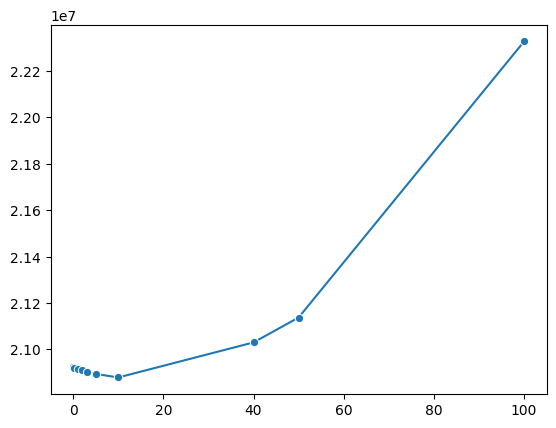

In [27]:
aplhas=[0.001,0.1,1,2,3,5,10,40,50,100]
mses=[]

for a in aplhas:
   lasso_model=linear_model.Lasso(alpha=a)
   lasso_model.fit(X_train,y_train)
   y_pred=lasso_model.predict(X_test)
   mses.append(mean_squared_error(y_test,y_pred))

for alpha, mse in zip(aplhas, mses):
    print(f"alpha={alpha}, mse={mse}")

sns.lineplot(x=aplhas,y=mses,marker="o")

In [37]:
from sklearn.linear_model import LassoCV
a=[0.001,0.1,1,2,3,5,10,40,50,100]

lasso_model=LassoCV(
       alphas=a,
       cv=5,
       max_iter=1000,
       random_state=42
)
   
lasso_model.fit(X_train,y_train)
print("best alpha:",lasso_model.alpha_)

y_pred=lasso_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
print("mse",mse)

best alpha: 0.001
mse 20922596.52800621
